# Test approach to make polygons non-overlapping
The goal of this is to take a set of polygons which may overlap arbitrarily and produce a new set of polygons. This should represent the "core" region of each input polygon, where the geometry represents only the areas which are furthest interior to the given polygon, out of all potential polygons. This forms a non-overlapping partition.

In [1]:
import shapely
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from itertools import product

from tree_detection_framework.utils.geometric import (
    split_overlapping_region,
    make_polygon_set_nonoverlapping,
)

# Test pairwise case
First ensure that different situations of pairwise overlap look appropriate

In [2]:
# Create the first box
box1 = shapely.geometry.box(0, 0, 1, 1)

# Horizontal overlap

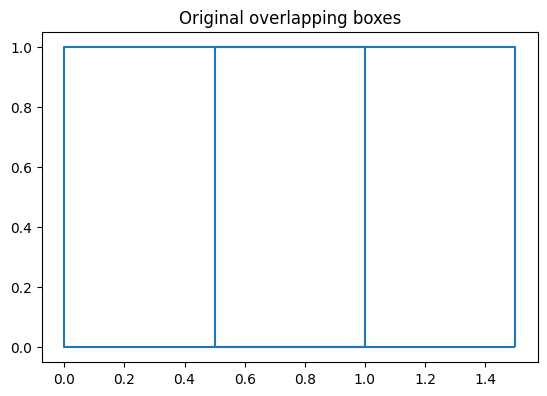

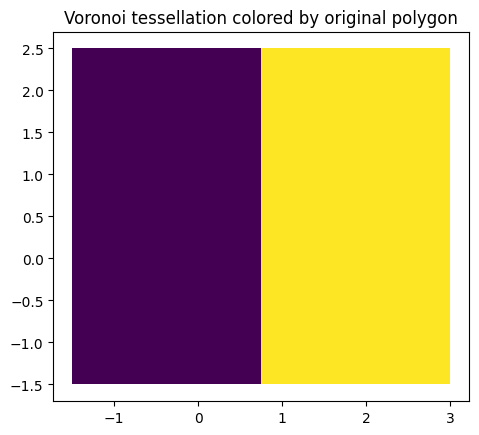

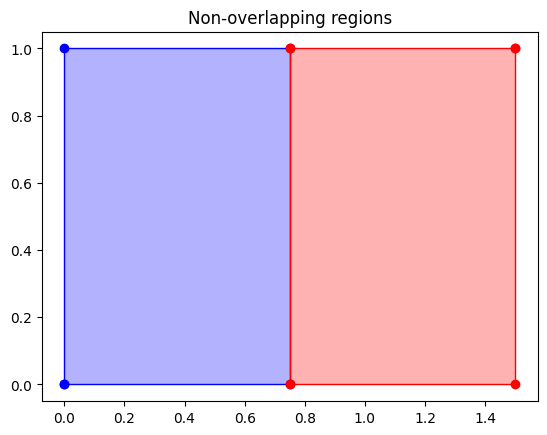

(<POLYGON ((0 0, 0 1, 0.75 1, 0.75 0, 0 0))>,
 <POLYGON ((1.5 1, 1.5 0, 0.75 0, 0.75 1, 1.5 1))>)

In [3]:
# Create two overlapping squares, shifted by 0.5 in only x
box2 = shapely.affinity.translate(box1, 0.5, 0)

# Visualize
boxes = gpd.GeoSeries([box1, box2])
ax = boxes.boundary.plot()
ax.set_title("Original overlapping boxes")
plt.show()
# Show splitting
split_overlapping_region(box1, box2, vis=True)

# Diagonal overlap

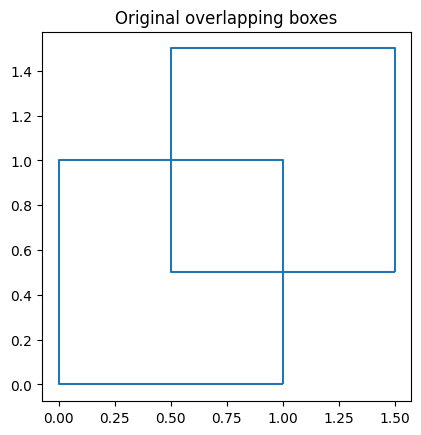

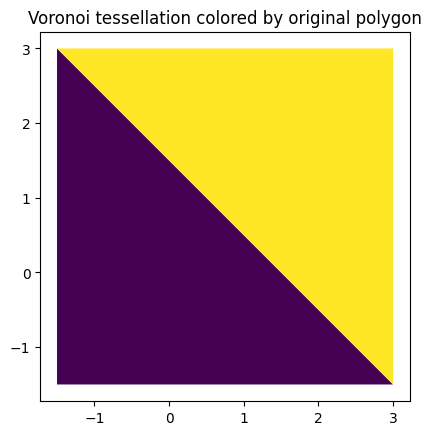

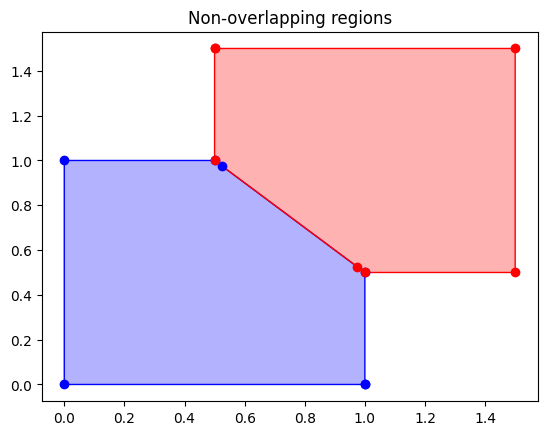

(<POLYGON ((1 0, 0 0, 0 1, 0.5 1, 0.525 0.975, 1 0.5, 1 0))>,
 <POLYGON ((0.5 1.5, 1.5 1.5, 1.5 0.5, 1 0.5, 0.975 0.525, 0.5 1, 0.5 1.5))>)

In [4]:
box2 = shapely.affinity.translate(box1, 0.5, 0.5)

# Visualize
boxes = gpd.GeoSeries([box1, box2])
ax = boxes.boundary.plot()
ax.set_title("Original overlapping boxes")
plt.show()
# Show splitting
split_overlapping_region(box1, box2, vis=True)

# Edge overlap

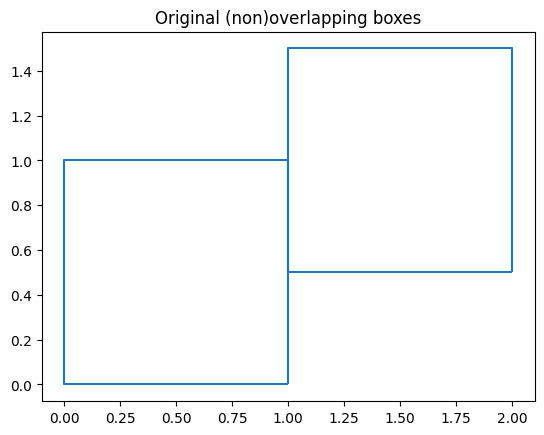

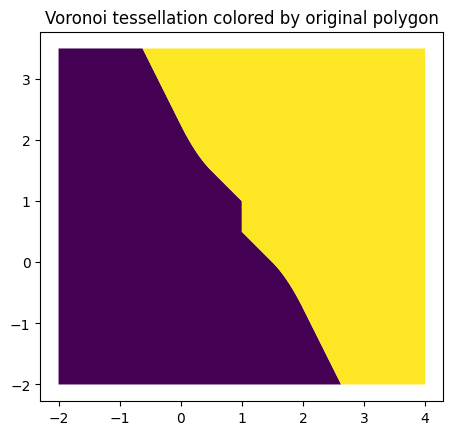

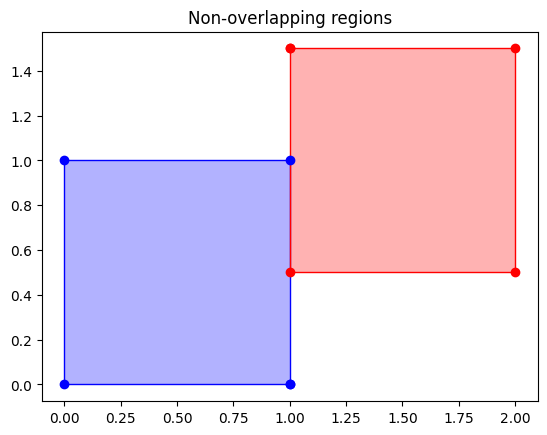

(<POLYGON ((1 0, 0 0, 0 1, 1 1, 1 0))>,
 <POLYGON ((1 1.5, 2 1.5, 2 0.5, 1 0.5, 1 1.5))>)

In [5]:
# Create two overlapping squares, shifted by 0.5 in only x
box2 = shapely.affinity.translate(box1, 1, 0.5)

# Visualize
boxes = gpd.GeoSeries([box1, box2])
ax = boxes.boundary.plot()
ax.set_title("Original (non)overlapping boxes")
plt.show()
# Show splitting
split_overlapping_region(box1, box2, vis=True)

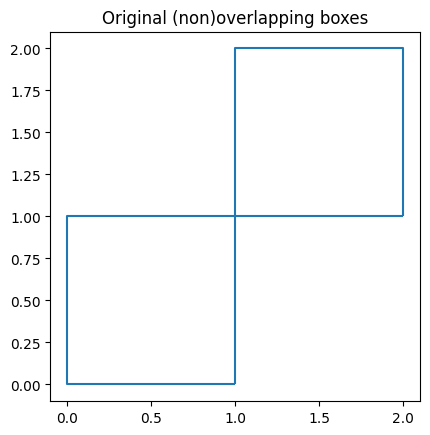

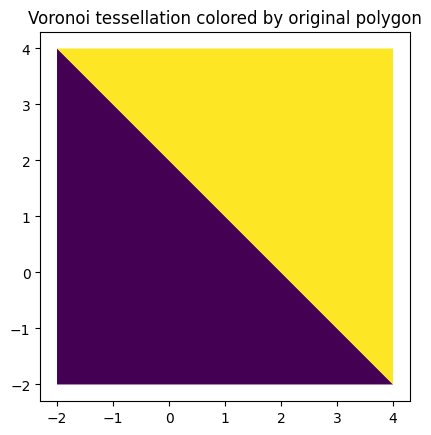

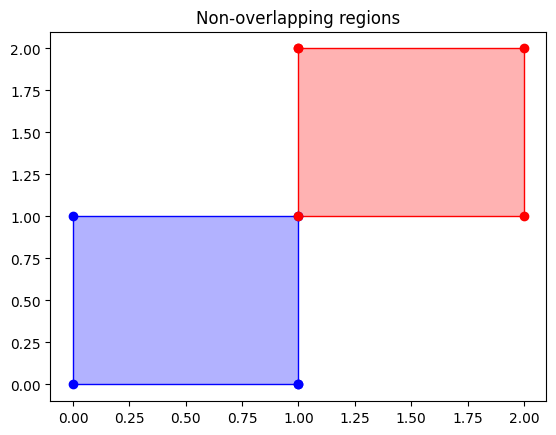

(<POLYGON ((1 0, 0 0, 0 1, 1 1, 1 0))>, <POLYGON ((1 2, 2 2, 2 1, 1 1, 1 2))>)

In [6]:
# Create two overlapping squares, shifted by 0.5 in only x
box1 = shapely.geometry.box(0, 0, 1, 1)
box2 = shapely.geometry.box(1, 1, 2, 2)

# Visualize
boxes = gpd.GeoSeries([box1, box2])
ax = boxes.boundary.plot()
ax.set_title("Original (non)overlapping boxes")
plt.show()
# Show splitting
split_overlapping_region(box1, box2, vis=True)

# Full non-overlapping

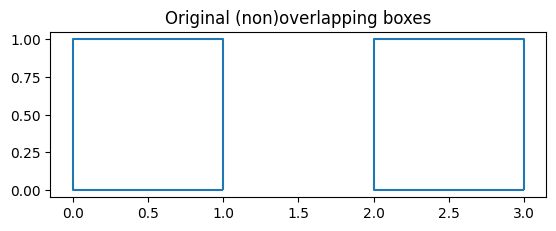

(<POLYGON ((1 0, 1 1, 0 1, 0 0, 1 0))>, <POLYGON ((3 0, 3 1, 2 1, 2 0, 3 0))>)

In [7]:
# Create two overlapping squares, shifted by 2.0 in x so that they don't overlap
box2 = shapely.affinity.translate(box1, 2.0, 0)

# Visualize
boxes = gpd.GeoSeries([box1, box2])
ax = boxes.boundary.plot()
ax.set_title("Original (non)overlapping boxes")
plt.show()
# Show splitting
split_overlapping_region(box1, box2, vis=True)

# Compute "core" areas
Using a set of tiled regions, compute the "core" region that is central to each and nonoverlapping.

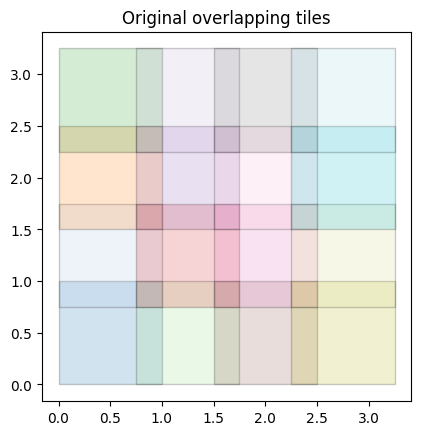

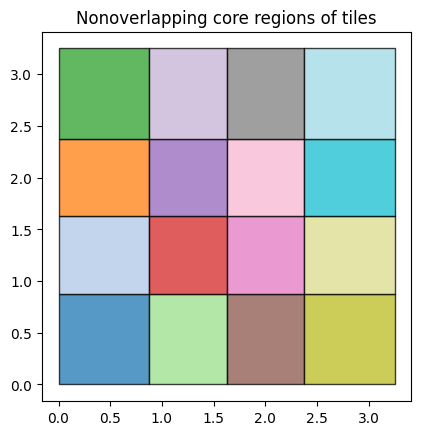

In [8]:
box_template = shapely.geometry.box(0, 0, 1, 1)
boxes = [
    shapely.affinity.translate(box_template, dx, dy)
    for dx, dy in product(np.arange(0, 3, 0.75), np.arange(0, 3, 0.75))
]

gpd.GeoDataFrame(geometry=boxes).plot(cmap="tab20", edgecolor="k", alpha=0.20)
plt.title("Original overlapping tiles")
plt.show()

nonoverlapping_polygons = make_polygon_set_nonoverlapping(boxes, vis=False)

gpd.GeoDataFrame(geometry=nonoverlapping_polygons).plot(
    cmap="tab20", edgecolor="k", alpha=0.75
)
plt.title("Nonoverlapping core regions of tiles")
plt.show()

# Compute "core" with subset of boxes
To simulate more complex cases, take a subset of boxes and recompute the core region.

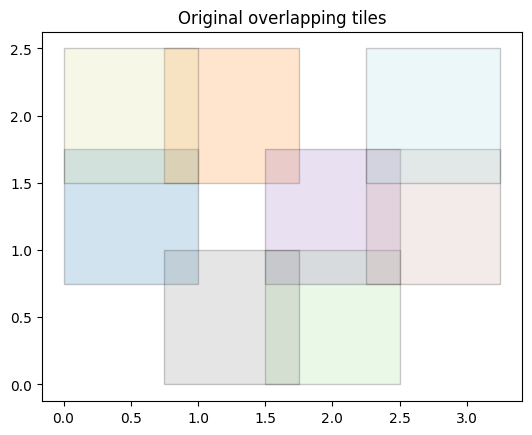

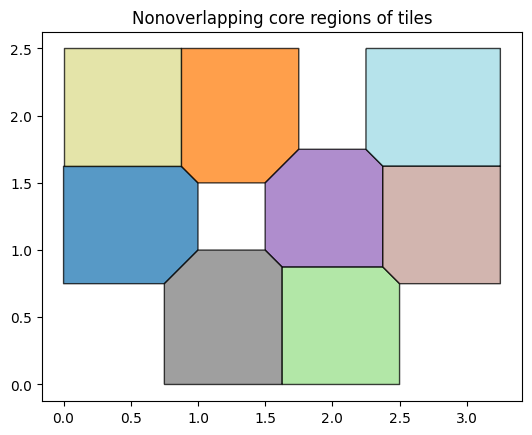

In [9]:
# Set seed to None for actual random sampling
np.random.seed(0)
boxes_subset = np.random.choice(boxes, size=8, replace=False)

gpd.GeoDataFrame(geometry=boxes_subset).plot(cmap="tab20", edgecolor="k", alpha=0.20)
plt.title("Original overlapping tiles")
plt.show()

nonoverlapping_polygons = make_polygon_set_nonoverlapping(boxes_subset, vis=False)

gpd.GeoDataFrame(geometry=nonoverlapping_polygons).plot(
    cmap="tab20", edgecolor="k", alpha=0.75
)
plt.title("Nonoverlapping core regions of tiles")
plt.show()